In [1]:
import cmdstanpy
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from cmdstanpy import CmdStanModel
from discourse.utils import read_rda
from discourse.utils.plots import scatter
cmdstanpy.install_cmdstan();

CmdStan install directory: /Users/cwf25/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


In [2]:
seed = 9

In [3]:
df = read_rda('data/demo.Rda')
df.head().style.hide(axis='index')

y,time
0.795570,0.000000
0.174560,0.500000
0.774322,1.000000
3.083851,1.500000
2.163227,2.000000


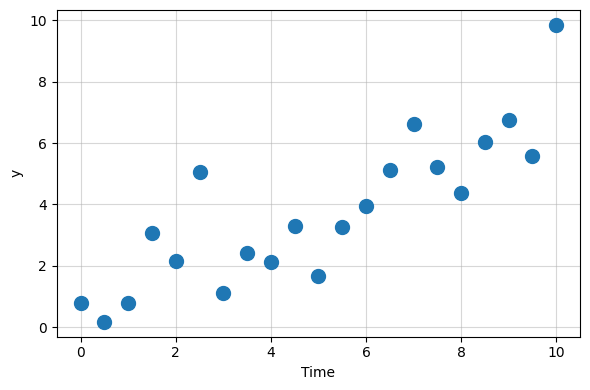

In [4]:
scatter(df['time'], df['y'], c=None, x_label='Time', y_label='y')

In [5]:
# Only want to solve the ODE at unique time points to reduce runtime
time = np.sort(df['time'].unique())

# Dictionary of data corresponding to the model definition in 'cmdstanpy.stan'
stan_data = {
    'N': len(df),
    'T': len(time),
    'y': df['y'],
    't': time,
    't_idx': [np.where(df == t)[0].item() + 1 for t in df['time']],
    'include_likelihood': True
}